In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Setting seed untuk reproduksibilitas
np.random.seed(42)

# Jumlah sampel: 5000 per grup (Total 10.000)
n_users = 10000
user_ids = range(1, n_users + 1)

# Assign kelompok secara acak 50:50
groups = np.random.choice(['A', 'B'], size=n_users, p=[0.5, 0.5])

# Generate tanggal secara acak dalam 30 hari terakhir
end_date = datetime.now()
start_date = end_date - timedelta(days=30)
timestamps = [start_date + timedelta(seconds=np.random.randint(0, 60*60*24*30)) for _ in range(n_users)]

# Generate metrik berdasarkan kelompok
purchased = []
clicked = []
revenue = []

for g in groups:
    if g == 'A': # Kontrol (CR 10%)
        p = np.random.binomial(1, 0.10)
        # Klik add to cart biasanya lebih tinggi, misal 40%
        c = np.random.binomial(1, 0.40)
    else: # Treatment (CR 13% - Uplift 30%)
        p = np.random.binomial(1, 0.13)
        c = np.random.binomial(1, 0.45) # Treatment juga naikkan klik

    purchased.append(p)
    clicked.append(c)
    # Jika tidak beli, revenue 0. Jika beli, rata-rata 150rb dengan std 50rb
    if p == 1:
        rev = np.random.normal(150000, 50000)
        rev = max(rev, 10000) # minimal 10k
    else:
        rev = 0
    revenue.append(rev)

# Buat DataFrame
df = pd.DataFrame({
    'user_id': user_ids,
    'timestamp': timestamps,
    'group': groups,
    'clicked_add': clicked,
    'purchased': purchased,
    'revenue': revenue
})

# Sorting by time
df = df.sort_values('timestamp').reset_index(drop=True)

# Simpan ke CSV
df.to_csv('ab_test_ecommerce.csv', index=False)
print(df.head())
print(df.groupby('group')[['purchased']].mean())

   user_id                  timestamp group  clicked_add  purchased  \
0     9591 2026-06-23 01:54:48.639749     B            1          0   
1     7082 2026-06-23 01:56:56.639749     B            1          0   
2     6685 2026-06-23 02:07:26.639749     B            0          0   
3     6914 2026-06-23 02:15:36.639749     A            1          0   
4     9297 2026-06-23 02:16:27.639749     B            0          1   

         revenue  
0       0.000000  
1       0.000000  
2       0.000000  
3       0.000000  
4  194031.717476  
       purchased
group           
A       0.098700
B       0.135865


In [2]:
!pip install pandas numpy scipy statsmodels matplotlib seaborn

In [3]:
from scipy.stats import chi2_contingency

# Cek SRM
obs = df['group'].value_counts().sort_index()
chi2, p, dof, exp = chi2_contingency([obs])
print(f"SRM P-value: {p}")
if p < 0.05:
    print("WARNING: SRM terdeteksi! Alokasi sample tidak seimbang.")

SRM P-value: 1.0


  group  users  conversion    clicks   avg_revenue
0     A   5076    0.098700  0.400709  15105.579391
1     B   4924    0.135865  0.453290  20232.288637


/tmp/ipykernel_4387/2987713394.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x='group', y='purchased', ci=95)


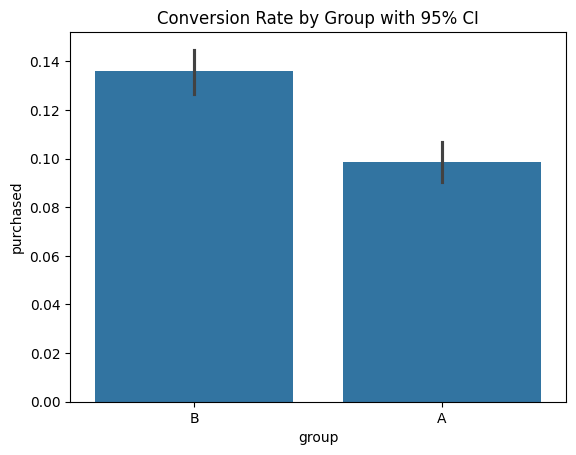

In [4]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns

summary = df.groupby('group').agg(
    users=('user_id', 'count'),
    conversion=('purchased', 'mean'),
    clicks=('clicked_add', 'mean'),
    avg_revenue=('revenue', 'mean')
).reset_index()
print(summary)

# Visualisasi
sns.barplot(data=df, x='group', y='purchased', ci=95)
plt.title('Conversion Rate by Group with 95% CI')
plt.show()

In [10]:
#Uji Hipotesis
from statsmodels.stats.proportion import proportions_ztest

# Hitung jumlah sukses dan jumlah observasi
count = df.groupby('group')['purchased'].sum().values
nobs = df.groupby('group')['purchased'].count().values

# H0: prop_A >= prop_B. Alternatif: prop_A < prop_B (artinya B > A)
stat, p_value = proportions_ztest(count, nobs, alternative='smaller')

print(f"Z-statistic: {stat:.4f}")
print(f"P-value (one-tailed): {p_value:.8f}")

alpha = 0.05
if p_value < alpha:
    print("Kesimpulan: Tolak H0. Ada bukti kuat bahwa tombol Hijau meningkatkan konversi.")
else:
    print("Kesimpulan: Gagal tolak H0. Tidak ada bukti signifikan.")

Z-statistic: -5.7808
P-value (one-tailed): 0.00000000
Kesimpulan: Tolak H0. Ada bukti kuat bahwa tombol Hijau meningkatkan konversi.


In [6]:
#Analisis Revenue
from scipy.stats import mannwhitneyu

rev_a = df[df['group'] == 'A']['revenue']
rev_b = df[df['group'] == 'B']['revenue']

# Uji satu arah: apakah revenue B > A?
u_stat, p_value_mw = mannwhitneyu(rev_b, rev_a, alternative='greater')
print(f"Mann-Whitney P-value: {p_value_mw:.8f}")

Mann-Whitney P-value: 0.00000001


In [11]:
#effect trust & CI
from statsmodels.stats.proportion import confint_proportions_2indep

cr_a = count[0] / nobs[0]
cr_b = count[1] / nobs[1]

abs_lift = cr_b - cr_a
rel_lift = (abs_lift / cr_a) * 100

print(f"CR A: {cr_a:.2%}")
print(f"CR B: {cr_b:.2%}")
print(f"Absolute Lift: {abs_lift:.2%}")
print(f"Relative Lift: {rel_lift:.2f}%")

# Hitung CI 95% untuk selisih
ci_low, ci_high = confint_proportions_2indep(count[1], nobs[1], count[0], nobs[0], alpha=0.05)
print(f"CI 95% untuk selisih (B - A): [{ci_low:.2%}, {ci_high:.2%}]")

CR A: 9.87%
CR B: 13.59%
Absolute Lift: 3.72%
Relative Lift: 37.65%
CI 95% untuk selisih (B - A): [2.46%, 4.98%]


In [12]:
#Business Conslusion
# Contoh Kesimpulan Akhir (akan dimasukkan ke dalam laporan)
print("\n===== REKOMENDASI AKHIR =====")
if p_value < 0.05 and abs_lift > 0.01: # Misal MDE = 1%
    print("✅ LANJUTKAN: Tombol Hijau terbukti secara statistik dan praktis")
    print("   meningkatkan konversi. Tim produk disarankan untuk deploy ke 100% traffic.")
else:
    print("❌ TIDAK LANJUTKAN: Tidak ada bukti cukup atau efek terlalu kecil.")
    print("   Saran: Uji coba dengan variasi lain (misal: warna oranye atau copywriting).")


===== REKOMENDASI AKHIR =====
✅ LANJUTKAN: Tombol Hijau terbukti secara statistik dan praktis
   meningkatkan konversi. Tim produk disarankan untuk deploy ke 100% traffic.


/tmp/ipykernel_4387/3210206051.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x='group', y='purchased', ci=95, ax=axes[0], palette=['skyblue', 'lightgreen'])
/tmp/ipykernel_4387/3210206051.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='group', y='purchased', ci=95, ax=axes[0], palette=['skyblue', 'lightgreen'])
/tmp/ipykernel_4387/3210206051.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['revenue']>0], x='group', y='revenue', ax=axes[1], palette=['skyblue', 'lightgreen'])


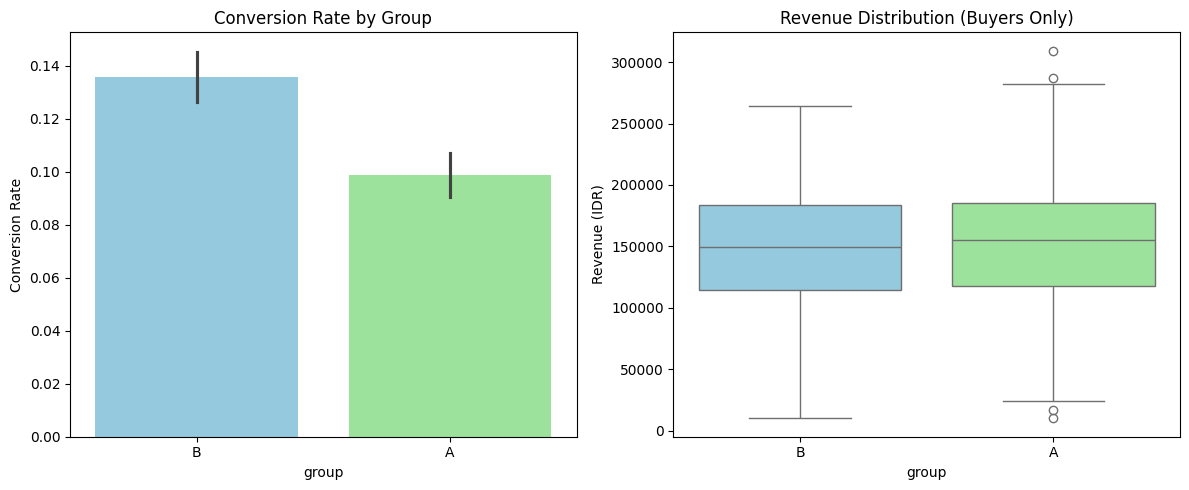

In [13]:
#visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Conversion Rate
sns.barplot(data=df, x='group', y='purchased', ci=95, ax=axes[0], palette=['skyblue', 'lightgreen'])
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion Rate')

# Plot 2: Revenue Distribution (Boxplot)
sns.boxplot(data=df[df['revenue']>0], x='group', y='revenue', ax=axes[1], palette=['skyblue', 'lightgreen'])
axes[1].set_title('Revenue Distribution (Buyers Only)')
axes[1].set_ylabel('Revenue (IDR)')

plt.tight_layout()
plt.savefig('ab_test_report.png', dpi=300)
plt.show()